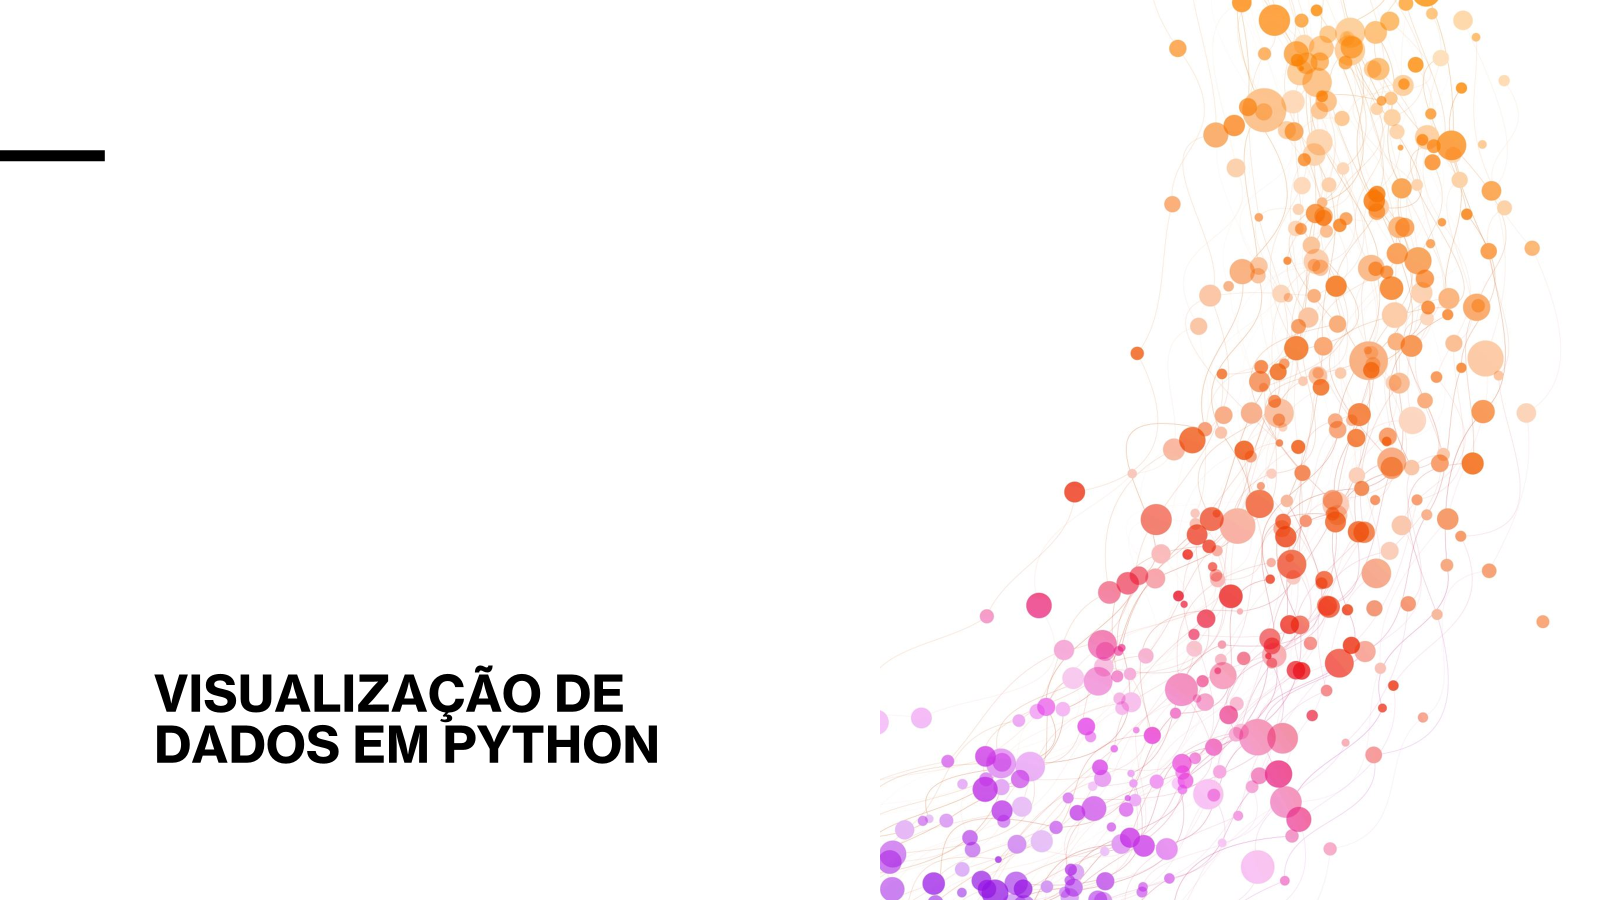

# Bibliotecas Principais

1. **Matplotlib**: Biblioteca base para criação de gráficos
2. **Seaborn**: Melhora esteticamente os gráficos do Matplotlib e simplifica visualizações estatísticas
3. **Plotly**: Cria visualizações interativas e dinâmicas
4. **Pandas Plotting**: Integração direta com DataFrames
5. **Geopandas**: Especializada em visualização geográfica

## 1. Gráfico de linhas
##### Sintaxe básica:
``` Python
    plt.plot(x, y)

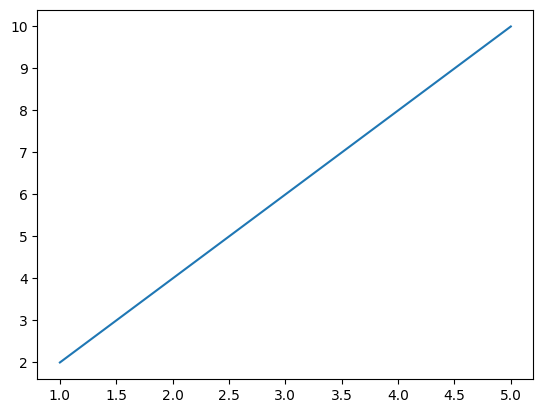

In [2]:
import matplotlib.pyplot as plt

# Definição dos dados 
x = [1,2,3,4,5]
y = [2,4,6,8,10]

plt.plot(x,y)# Criação de grafico de linha

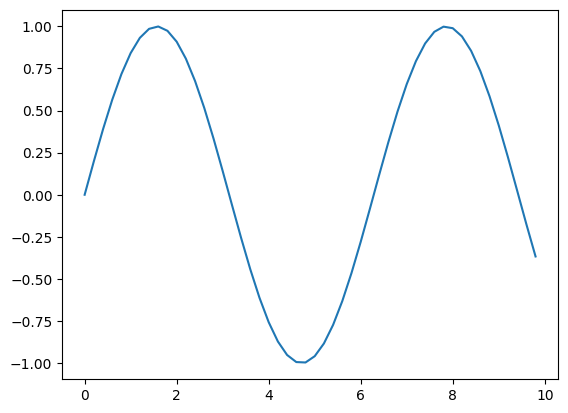

In [12]:
import numpy as np

x = np.arange(0,10,0.2) # Cria valores para o eixo das abscissas 
y = np.sin(x)

plt.plot(x,y)
plt.show()

#### Gráfico de linhas (adicionando elementos)

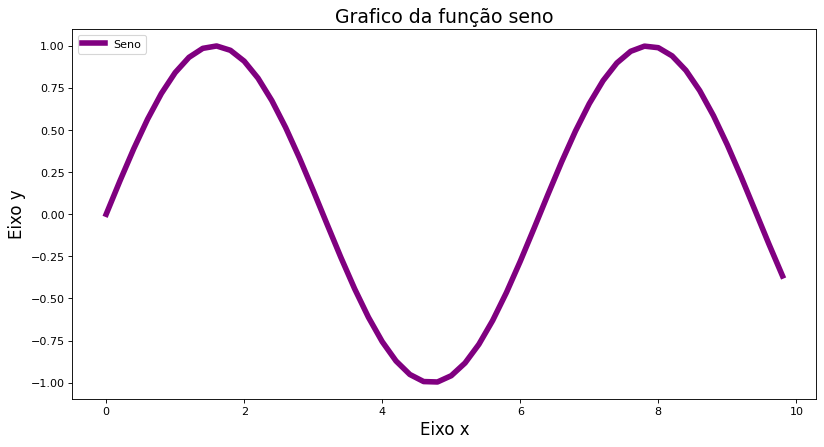

In [13]:
# Cria uma figura 12x6 polegadas,dpi cria 80 pontos por polegada
plt.figure(figsize=(12,6), dpi=80) 
# DPI - Dots Per Inch - É uma medida de densidade que define a qualidade da imagem
plt.plot(x,y, color = "purple", label = "Seno", linewidth = 5)
plt.title("Grafico da função seno", fontsize=17)
plt.xlabel("Eixo x", fontsize = 15)
plt.ylabel("Eixo y", fontsize = 15)
plt.legend(loc = "upper left")
plt.show()

### 2. Gráficos Multiplos e Subplot
#### Gráficos em uma mesma figura
- Com a função subplots (), você pode desenhar vários gráficos em uma figura:
- Nesse primeiro exemplo, vamos plotar dois sub gráficos de linhas

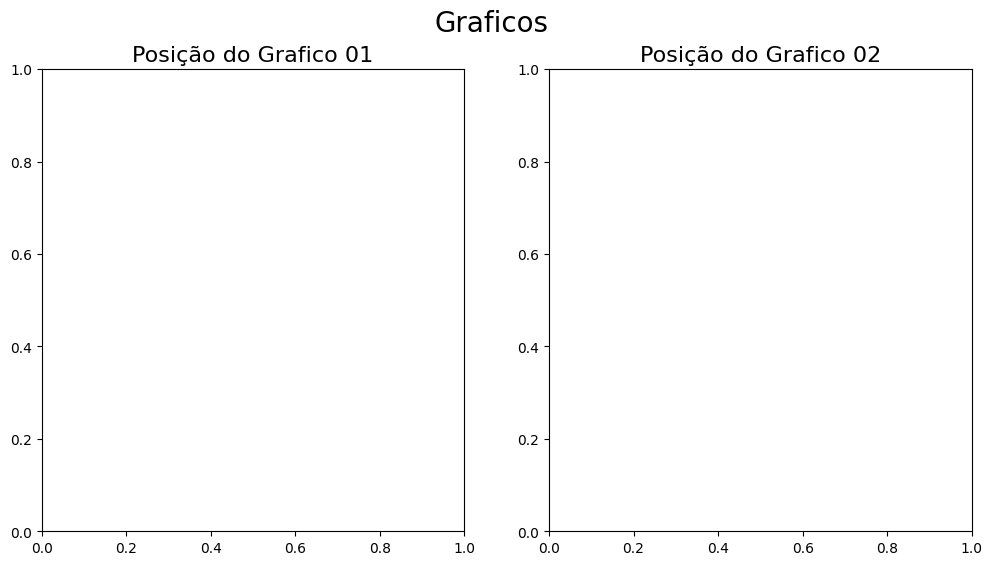

In [17]:
plt.figure(figsize=(12,6)) 
plt.subplot(1,2,1)
plt.title("Posição do Grafico 01", fontsize=16)

plt.subplot(1,2,2)
plt.title("Posição do Grafico 02", fontsize=16)

plt.suptitle("Graficos", fontsize=20)

plt.show()

### Gráficos lado a lado

C:\Users\51002631807\AppData\Local\Temp\ipykernel_21396\1182759077.py:16: RuntimeWarning: divide by zero encountered in log
  plt.plot(x , np.log(x))


Text(0.5, 0.98, 'Graficos')

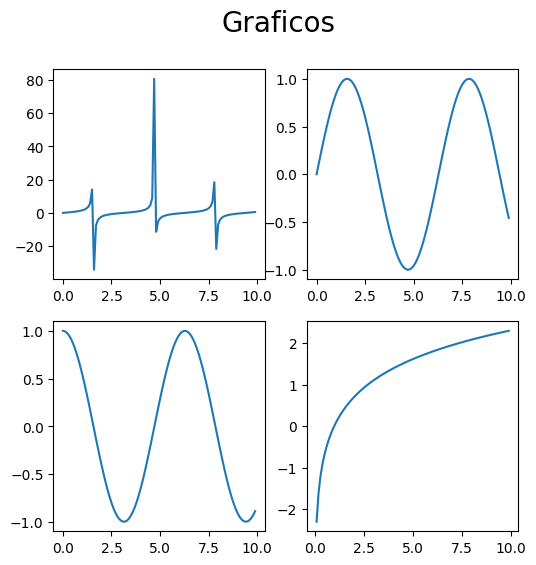

In [23]:
plt.figure(figsize=(6,6)) 
x = np.arange(0,10,0.1)
plt.subplot(2,2,1)
plt.plot(x , np.tan(x))


plt.subplot(2,2,2)
plt.plot(x, np.sin(x))


plt.subplot(2,2,3)
plt.plot(x , np.cos(x))


plt.subplot(2,2,4)
plt.plot(x , np.log(x))


plt.suptitle("Graficos", fontsize=20)


### Gráfico um em cima do outro

### Múltiplos Gráficos com Subplot
- É possível plotar quantos gráficos quiser em uma figura, só precisar informar a quantidade de linhas e colunas que terá a figura, além do índice do gráfico.

### 3. Visualização de Dados Numéricos
#### Histograma

In [25]:
data = np.random.normal(0,1,1000)
#data

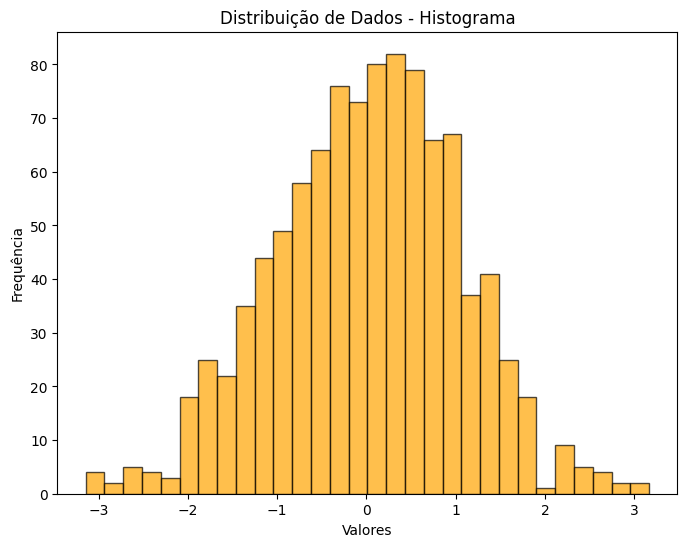

In [31]:
plt.figure(figsize =(8,6))
plt.hist(data,bins = 30, edgecolor='black', color = 'orange' , alpha=0.7)
plt.title('Distribuição de Dados - Histograma')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

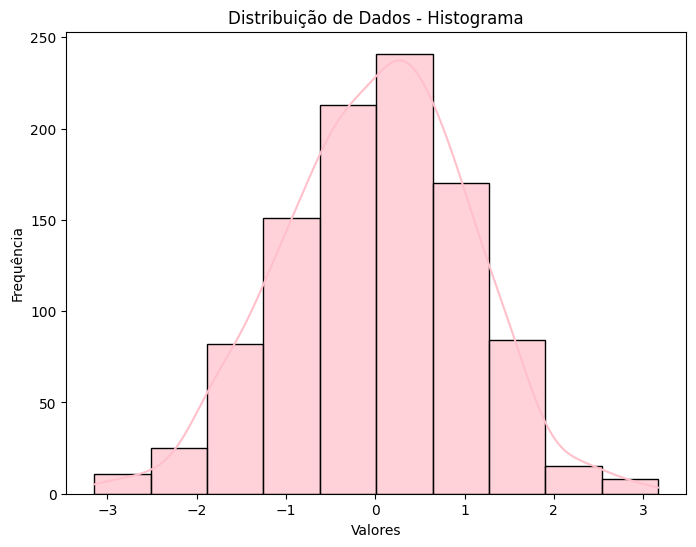

In [34]:
import seaborn as sns

plt.figure(figsize =(8,6))

# KDE - é uma curva continua suavizada que aproxima a distribuição subjacente aos dados 
sns.histplot(data,kde = True,bins = 10, edgecolor='black', color = 'pink' , alpha=0.7)
plt.title('Distribuição de Dados - Histograma')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

### 4. Gráficos boxplot com Matplotlib e Seaborn
- Exemplos de boxplot, com a base de dados flores iris, que tem 3 tipos de flores

In [35]:
base_dados = sns.load_dataset('iris')
base_dados.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


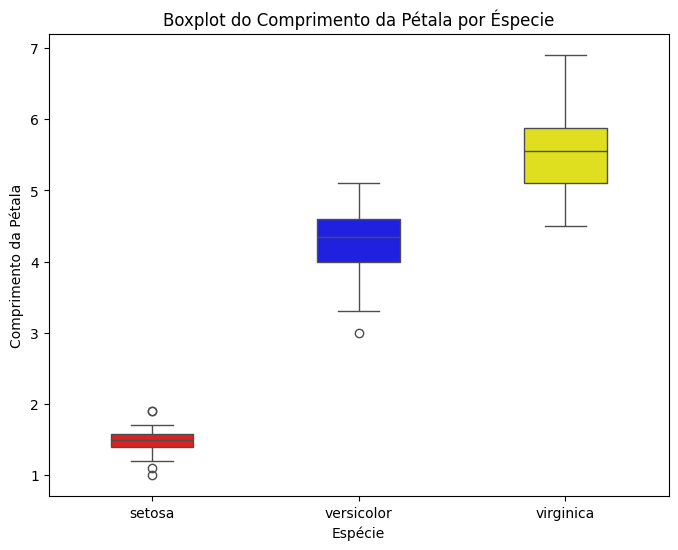

In [36]:
plt.figure(figsize=(8,6))
sns.boxplot(x = 'species', y = 'petal_length', hue ='species',data = base_dados,width=0.4,palette=['red', 'blue', 'yellow'] )


plt.title("Boxplot do Comprimento da Pétala por Éspecie")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da Pétala")
plt.show()

### Mult Boxplot com Matplotlib

In [38]:
setosa = base_dados[base_dados['species'] == 'setosa']['petal_length']
versicolor = base_dados[base_dados['species'] == 'versicolor']['petal_length']
virginica = base_dados[base_dados['species'] == 'virginica']['petal_length']

dados = [setosa, versicolor, virginica]

AttributeError: 'Line2D' object has no attribute 'set_facecolor'

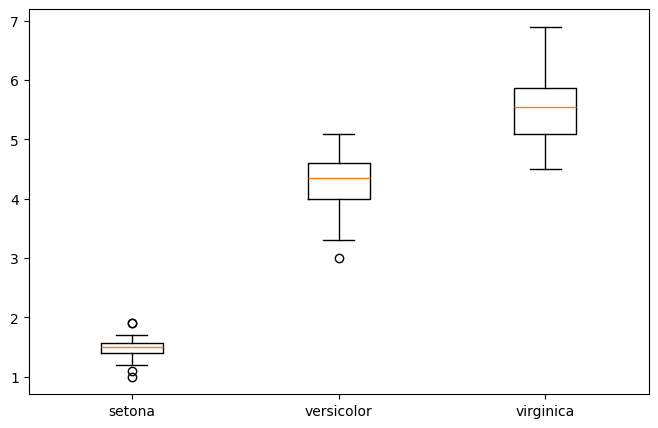

In [42]:
plt.figure(figsize=(8,5))
box = plt.boxplot(dados, tick_labels=['setona','versicolor','virginica'])
#box = plt.boxplot(dados,patch_artist=True, tick_labels=['setona','versicolor','virginica'])

for patch, cor in zip(box['boxes'],['purple','red','orange']):
    patch.set_facecolor(cor)


plt.title("Boxplot do Comprimento da Pétala por Éspecie")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da Pétala")
plt.show()

#### Formatando por partes

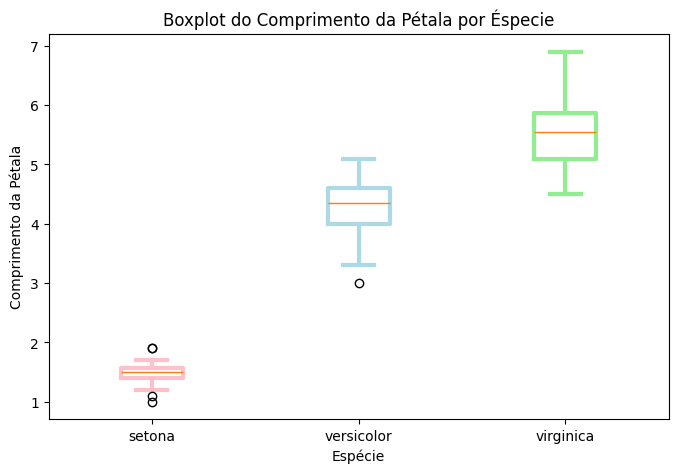

In [46]:
plt.figure(figsize=(8,5))
ticks =['setona','versicolor','virginica']
box = plt.boxplot(dados, tick_labels= ticks)
#box = plt.boxplot(dados,patch_artist=True, tick_labels=['setona','versicolor','virginica'])

cores = ['pink', 'lightblue', 'lightgreen']
# 1. Contorno das caixas
for i, bplot in enumerate(box['boxes']):
    bplot.set(color=cores[i],linewidth=3)

# 2. Whiskers(2 por caixa)
cores_whiskers = ['pink', 'pink', 'lightblue', 'lightblue','lightgreen', 'lightgreen']
for i, whiskers in enumerate(box['whiskers']):
    whiskers.set(color=cores_whiskers[i],linewidth=3)

# 3. Caps (extremidades)
for i, cap in enumerate(box['caps']):
    cap.set(color=cores_whiskers[i],linewidth=3)

# 4. Mediana
for i, median in enumerate(box['medians']):
    median.set(color=cores[i],linewidth=3)

plt.title("Boxplot do Comprimento da Pétala por Éspecie")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da Pétala")
plt.show()

### Mult Boxplot com Matplotlib Cor

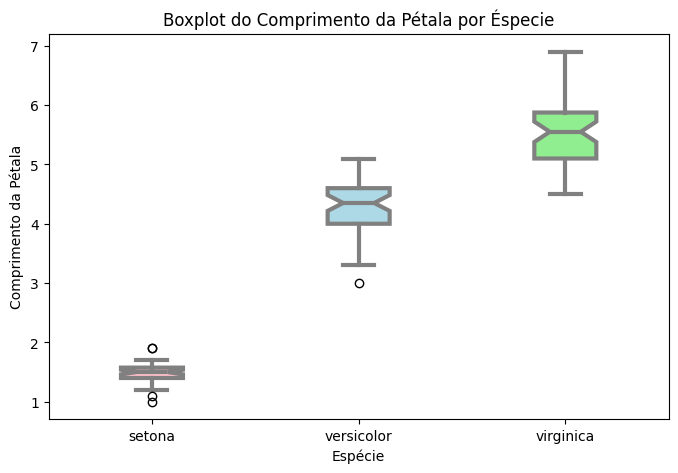

In [50]:
plt.figure(figsize=(8,5))
ticks =['setona','versicolor','virginica']
box = plt.boxplot(dados,notch = True, patch_artist= True,vert=True, tick_labels= ticks)
# NOTCH - Ativa o boxplot com entalhe ( notched boxplot)

# Cor do corpo
cores = ['pink', 'lightblue', 'lightgreen']
for i, bplot in enumerate(box['boxes']):
    bplot.set(color='gray',linewidth=3)
    bplot.set(facecolor = cores[i])

#Linhas de contorno
for whiskers in box['whiskers']:
    whiskers.set(color = 'gray', linewidth=3)

# Caps
for cap in box['caps']:
    cap.set(color = 'gray', linewidth=3)

# Mediana
for median in box['medians']:
    median.set(color = 'gray', linewidth=3)

plt.title("Boxplot do Comprimento da Pétala por Éspecie")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da Pétala")
plt.show()

### Boxplot, Gráfico de Disperção com Seaborn

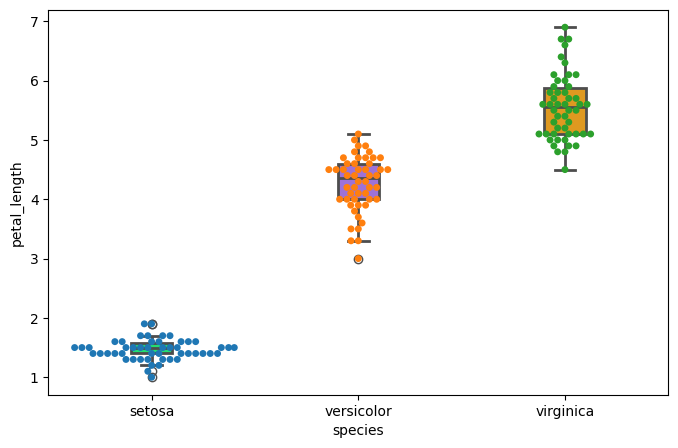

In [58]:
plt.figure(figsize=(8,5))

#Cores dos boxplot
colors = ['#03fc6f','#9a61e8', '#ffa200']
sns.boxplot(x = 'species', y = 'petal_length', hue ='species', width=0.2,
            data = base_dados, linewidth=2, 
            palette=colors, legend=False )

#ax =sns.stripplot(x = 'species', y = 'petal_length', hue ='species',data = base_dados)
ax =sns.swarmplot(x = 'species', y = 'petal_length', hue ='species',data = base_dados)

plt.show()

### Traçar gráfico de violino com seaborn

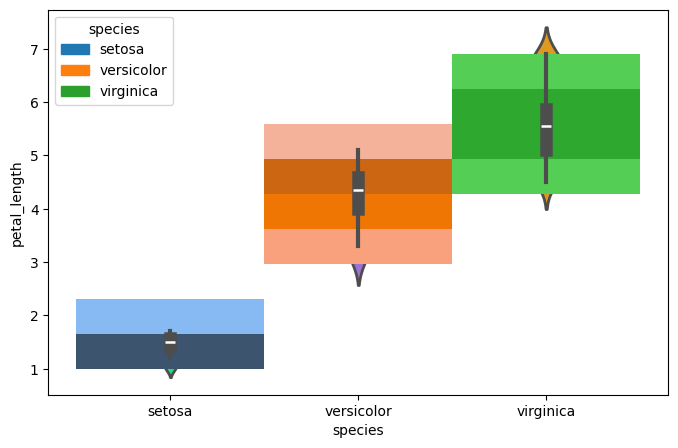

In [61]:
plt.figure(figsize=(8,5))

#Cores dos boxplot
colors = ['#03fc6f','#9a61e8', '#ffa200']
ax = sns.violinplot(x = 'species', y = 'petal_length', hue ='species',
            data = base_dados, linewidth=2, 
            palette=colors, legend=False )

ax =sns.histplot(x = 'species', y = 'petal_length', hue ='species',data = base_dados)
#ax =sns.swarmplot(x = 'species', y = 'petal_length', hue ='species',data = base_dados)

plt.show()

#### Estimativa da densidade

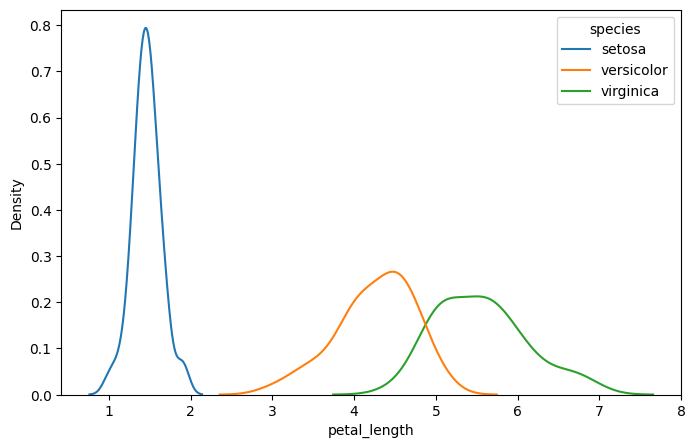

In [62]:
plt.figure(figsize=(8,5))


ax = sns.kdeplot(x ='petal_length', hue ='species', data = base_dados)

plt.show()

#### Extensão bo boxplot

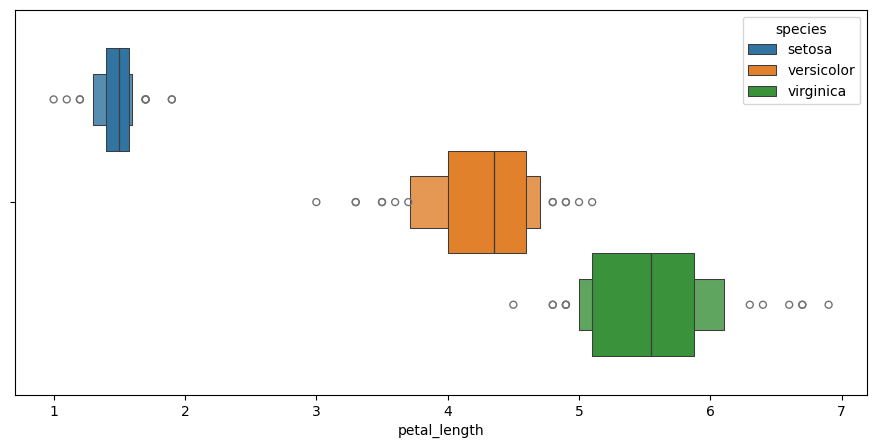

In [64]:
plt.figure(figsize=(11,5))

ax = sns.boxenplot(x ='petal_length', hue ='species', data = base_dados)

plt.show()

### 5. Visualização de Dados Categóricos
#### Gráfico de Barras

In [65]:
categorias = ['A','B','C','D','E']
valores = [15,30,45,10,40]

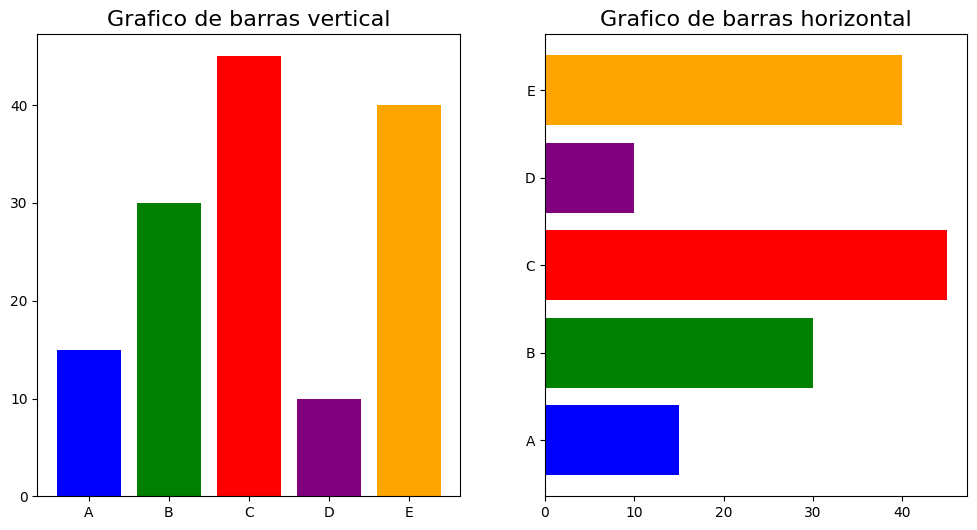

In [67]:
plt.figure(figsize=(12,6)) 

plt.subplot(1,2,1)
plt.bar(categorias,valores,color = ['blue','green','red','purple','orange'])
plt.title("Grafico de barras vertical", fontsize=16)

plt.subplot(1,2,2)
plt.barh(categorias,valores,color = ['blue','green','red','purple','orange'])
plt.title("Grafico de barras horizontal", fontsize=16)



plt.show()

In [69]:
import pandas as pd

df = pd.DataFrame({'Categorias': categorias, 'Valores': valores})
#df

,Categorias,Valores
0,A,15
1,B,30
2,C,45
3,D,10
4,E,40


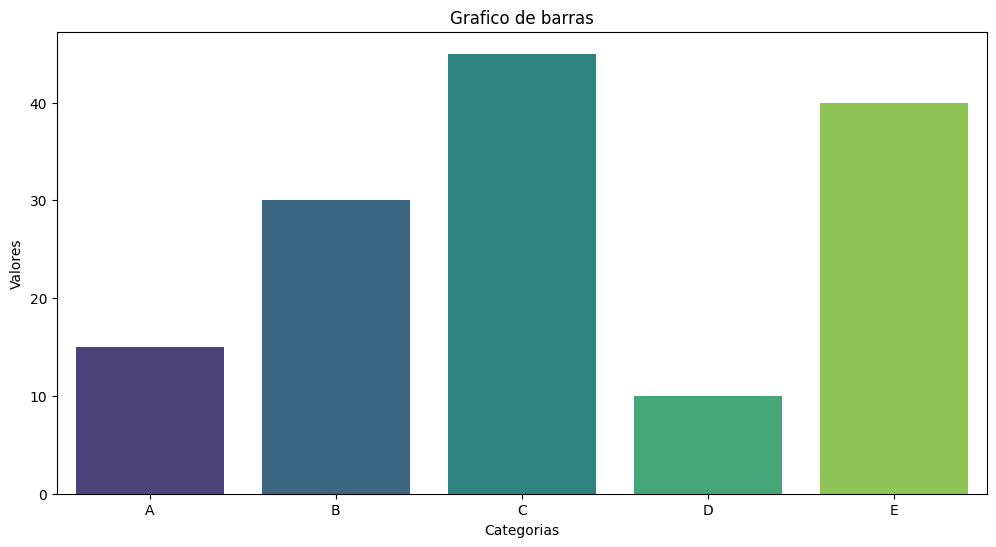

In [72]:
plt.figure(figsize=(12,6)) 

sns.barplot(x='Categorias',y='Valores', data=df, hue='Categorias', palette='viridis')
plt.title("Grafico de barras")

plt.show()

#### Gráfico de Torta ou Pizza

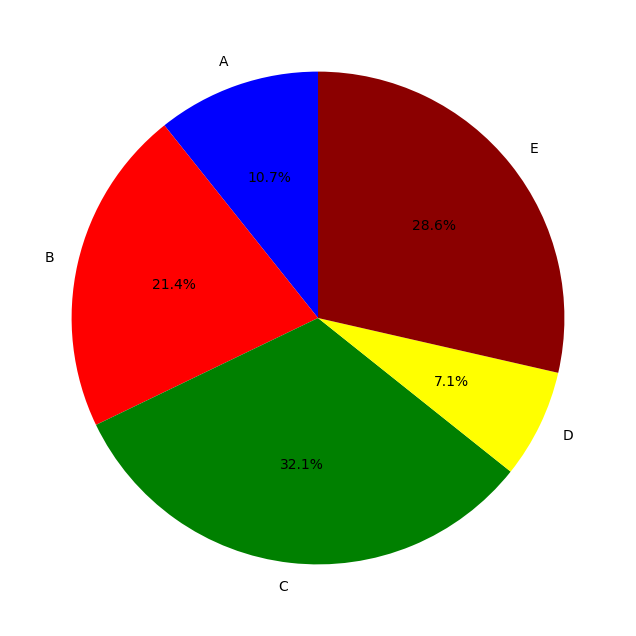

In [75]:
plt.figure(figsize=(8,8))

plt.pie(valores, labels=categorias, autopct='%1.1f%%', # Exibi o percentualcom uma casa decimal(ex: 25,3%)
        startangle=90, #Rociona o gráfico para iniciar a primeira fatia no topo
        colors=['blue','red','green','yellow','darkred'])
plt.show()

#### Plotly (interativo)

In [1]:
import plotly.express as px

dados = {
    "Categoria": ["A", "B", "C", "D"],
    "Valor": [10, 25, 15, 30]
}

fig = px.bar(
    dados,
    x="Categoria",
    y="Valor",
    title="Gráfico de barras interativo",
    labels={"Valor": "Quantidade", "Categoria": "Tipo"}
)

fig.show()

### 6. Visualização de Relações entre Variáveis
#### Scatter Plot

In [80]:
x = np.random.rand(100)
y = x + np.random.normal(0,0.1,100)


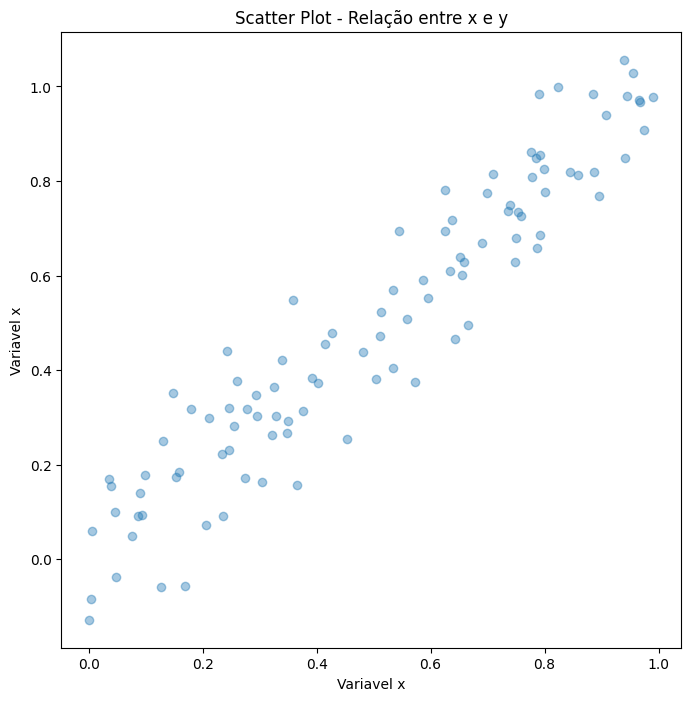

In [81]:
plt.figure(figsize=(8,8))
plt.scatter(x,y,alpha = 0.4)
plt.title('Scatter Plot - Relação entre x e y')
plt.xlabel('Variavel x')
plt.ylabel('Variavel x')

plt.show()


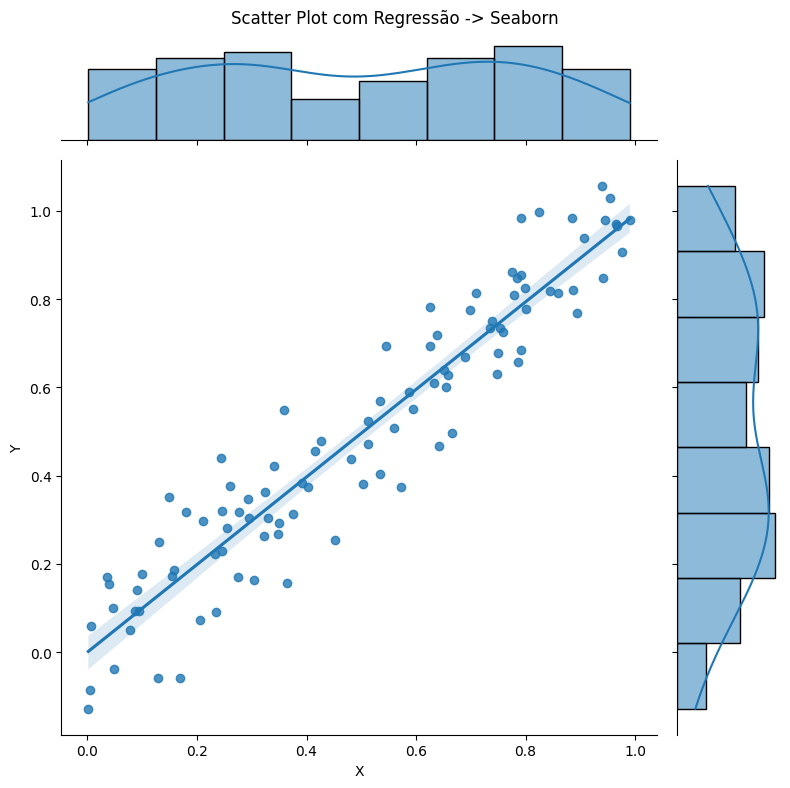

In [85]:
df = pd.DataFrame({'X':x,'Y':y})
# REG - Indica a dispersão com ajuste a regressão linear
sns.jointplot(x='X',y='Y',data=df,kind='reg',height=8)



plt.suptitle('Scatter Plot com Regressão -> Seaborn')
plt.tight_layout()
plt.show()

#### Heatmap (Matriz de Correlação)

In [86]:
data = pd.DataFrame(np.random.randn(100,8),columns=['A', 'B','C','D','E','F','G','H'])

cor = data.corr()


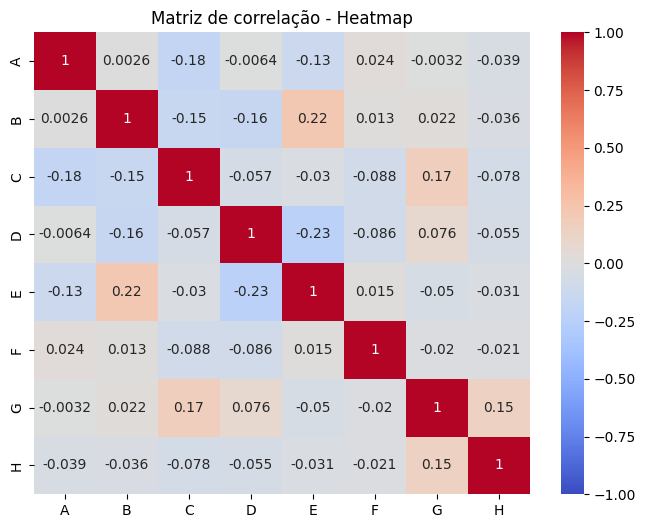

In [89]:
plt.figure(figsize=(8,6))
sns.heatmap(cor, annot=True, cmap='coolwarm',vmin=-1,vmax=1)
plt.title('Matriz de correlação - Heatmap')
plt.show()

### 6. Visualização de Séries Temporais

In [7]:
import numpy as np
import pandas as pd

# Gera uma sequência de datas a partir de uma data
dates = pd.date_range('2023-01-01',periods=100)
# Gera uma séria temporal - cumsum acumula os dados com base no anterior
values = np.cumsum(np.random.randn(100))

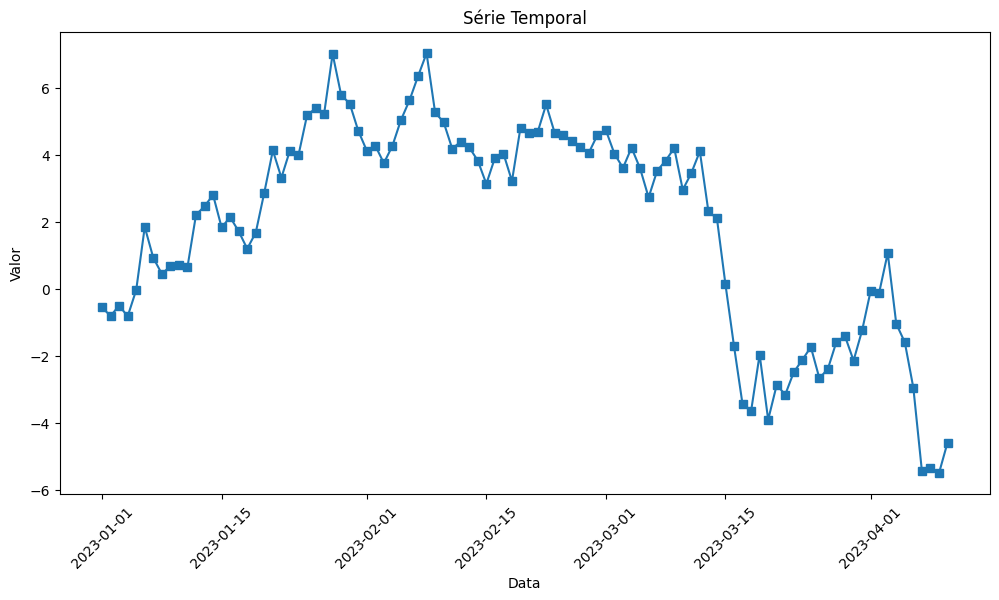

In [92]:
plt.figure(figsize=(12,6))
plt.plot(dates,values,marker='s',linestyle='-')

plt.title('Série Temporal')
plt.xlabel("Data")
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.show()

#### Série temporal interativa com Plotly

In [8]:


df = pd.DataFrame({'Data': dates, 'Valor': values})
fig = px.line(df, x='Data', y='Valor', title='Série Temporal interativa')
fig.update_xaxes(rangeslider_visible=True)#Exibe um controle deslizante
fig.show()

### Intervalos de modelagem de séries temporais
- A bibliteca tsmoothie serve para fazer a suavização de séries temporais e detecção de outliers de forma vetorizada.

In [1]:
#!pip install tsmoothie

### 7. Visualização de Dados Multidimensionais
#### Pair Plot

### 8. Visualizações Interativas Avançadas
#### Gráficos 3D com Matplotlib

Para plotar gráficos 3D é necessário importar um submódulo do Matplotlib

### Criando ambiente de plotagem do gráfico 3D

### Gráfico de linha no espaço 3D

### Parâmetros de Ângulo - Ex 01

### Parâmetros de Ângulo - Ex 02

### Gráfico de linha e de dispersão no espaço 3D
- Adicionando mais informações na plotagem do gráfico 
- Plotando uma espiral 3d com pontos

### Parâmetros de Ângulo - Ex 01

### Parâmetros de Ângulo - Ex 02

### Gráficos de contorno no Espaço 3D

### Parâmetros de Ângulo - Ex 01

### Parâmetros de Ângulo - Ex 02

### Gráfico de superfície no Espaço 3

### Parâmetros de Ângulo - Ex 01

### Parâmetros de Ângulo - Ex 02

### Gráficos de barras no Espaço 3D

### Parâmetros de Ângulo - Ex 01

### Parâmetros de Ângulo - Ex 02

#### Gráfico 3D Interativo

## Dashboard Interativo